In [70]:
import pickle
import numpy as np
import pandas as pd
import os.path as op
import itertools as it
from pathlib import Path
import matplotlib.pylab as plt
from lameg.util import get_files
import nibabel as nib
from scipy.spatial.distance import euclidean
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

In [71]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [72]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')


In [73]:
n_layers = 11
layers = np.arange(n_layers)
vx_loc, vx_adj, surf_norm = nib.load(Path("/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/multilayer.11.ds.link_vector.fixed.gii")).agg_data()
layers_loc = np.array(np.split(vx_loc, n_layers, axis=0))
cortical_thickness = np.array([euclidean(layers_loc[0, i, :], layers_loc[-1, i, :]) for i in range(layers_loc.shape[1])])

In [74]:
snr_res = Path("../output/snr_win_size_simulations/")
snr_files = get_files(snr_res, "*.pickle")

In [75]:
def annotate_mx(im, txt_mx, **textkw):
    kw = dict(
        horizontalalignment="center",
        verticalalignment="center"
    )
    kw.update(textkw)
    for r, c in it.product(range(txt_mx.shape[0]), range(txt_mx.shape[1])):
        im.axes.text(c, r, txt_mx[r, c], **kw)

def colorbar(mappable, label):
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax, label=label)
    plt.sca(last_axes)
    return cbar


def plot_mx(mx, title="", ax=False, labels=False, cbar=False, cmap="Spectral_r", norm=False, cbar_label=r"$\Delta$ FE"):
    if not ax:
        f, ax = plt.subplots(1, 1)
    else:
        ax = ax
    if not norm:
        iw = ax.imshow(mx, cmap=cmap)
    else:
        iw = ax.imshow(mx, cmap=cmap, norm=norm)
    if labels:
        ax.set_ylabel("Evaluation")
        ax.set_xlabel("Simulation")
        ax.set_xticks([0,n_layers-1])
        ax.set_xticklabels(['S','D'])
        ax.set_yticks([0,n_layers-1])
        ax.set_yticklabels(['S','D'])
        plt.suptitle(title)
        plt.tight_layout()
    if cbar:
        colorbar(iw, cbar_label)
    return iw


def norm_res(mx):
    norm = np.zeros(mx.shape)
    for l in range(mx.shape[1]):
        for t in range(mx.shape[2]):
            normed = mx[:,l,t] - np.min(mx[:,l,t])
            norm[:,l,t] = normed
    return norm


def find_peaks(mx, marker="*", return_annot=True):
    annot = np.zeros(mx.shape).astype(np.object_)
    peaks = []
    for l in range(mx.shape[1]):
        peak = np.argmax(mx[:, l]) # here is the problem (you find peak in evaluated!)
        annot[peak,l] = 1.0
        peaks.append(peak)
    peaks = np.array(peaks)
    annot_bin = np.copy(annot).astype(float)
    annot[annot==0.0] = None
    annot[annot==1.0] = marker
    if return_annot:
        return peaks, annot, annot_bin
    else:
        return peaks

def bootstrap_func(data, n_boot=1000, prop=0.5, func="mean"):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        if func == "mean":
            results.append(data[boot_rows].mean(axis=0))
        elif func == "sem":
            results.append(data[boot_rows].std(axis=0) / np.sqrt(prop_rows))
    return np.array(results)


def bootstrap(data, n_boot=1000, prop=0.5):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        results.append(data[boot_rows])
    return np.array(results)


def shuffled_peak_error(mx, ab=False):
    mx_sh = shuffle_mx(mx)
    peaks = find_peaks(mx_sh, return_annot=False)
    peaks = peaks - np.arange(mx.shape[0])
    if not ab:
        return peaks
    else:
        return np.abs(peaks)


def shuffle_mx(mx):
    mx_shape = mx.shape
    mx = mx.flatten()
    np.random.shuffle(mx)
    return mx.reshape(mx_shape)

In [76]:
fnms = [[i] + i.stem.split("_") for i in snr_files]
fnms = np.array(fnms)
map_fnms = np.array([i in [1, 3, 5, 7] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "snr","win_size"]
df_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
df_files["matrix"] = None
df_files.vx = df_files.vx.apply(lambda x: eval(x))
df_files.snr = df_files.snr.apply(lambda x: eval(x))
df_files.win_size = df_files.win_size.apply(lambda x: eval(x))
mxs = []
for ix, row in df_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    wois=output['wois']
    time=output['time']
    signal=output['signal']
    output = output["layerFs"]
    df_files.at[ix, "matrix"] = output

In [77]:
df_files

,filename,vx,snr,win_size,matrix
0,../output/snr_win_size_simulations/vx_10233_sn...,10233,-10,100,"[[[-2172.9640615159433, -2176.832099214495, -2..."
1,../output/snr_win_size_simulations/vx_10233_sn...,10233,-10,15,"[[[-2101.9569719953292, -2104.8333733347245, -..."
2,../output/snr_win_size_simulations/vx_10233_sn...,10233,-10,25,"[[[-2103.066792999188, -2100.4132302990924, -2..."
3,../output/snr_win_size_simulations/vx_10233_sn...,10233,-10,50,"[[[-2159.9595586021615, -2163.331179779165, -2..."
4,../output/snr_win_size_simulations/vx_10233_sn...,10233,-20,100,"[[[-3455.8618832331904, -3463.5861624998447, -..."
...,...,...,...,...,...
2395,../output/snr_win_size_simulations/vx_8838_snr...,8838,0,50,"[[[-2235.269678153343, -2240.562183159784, -22..."
2396,../output/snr_win_size_simulations/vx_8838_snr...,8838,5,100,"[[[-1621.070376699367, -1624.322734868509, -16..."
2397,../output/snr_win_size_simulations/vx_8838_snr...,8838,5,15,"[[[-1565.8606031963966, -1555.2405862969897, -..."
2398,../output/snr_win_size_simulations/vx_8838_snr...,8838,5,25,"[[[-1553.79845143338, -1558.2989371550464, -15..."


In [78]:
matrices_all = {i: {j: [] for j in win_sizes} for i in snrs}
annots_bin = {i: {j: [] for j in win_sizes} for i in snrs}

for vx in vertices:
    for snr_ix, snr in enumerate(snrs):
        for w_ix, win_size in enumerate(win_sizes):
            row = df_files.loc[
                (df_files.vx == vx) &
                (df_files.snr == snr) &
                (df_files.win_size == win_size)
            ]
            mx = row.matrix.values[0]
            t_idx=int(mx.shape[2]/2)
            mx = norm_res(mx)[:,:,t_idx]
            peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")

            matrices_all[snr][win_size].append(mx)
            annots_bin[snr][win_size].append(annot_bin)

In [79]:
vertices = df_files.vx.unique()
vertices.sort()
snrs = df_files.snr.unique()
snrs.sort()
win_sizes = df_files.win_size.unique()
win_sizes.sort()

In [80]:
matrices_all = {j: {i: [] for i in snrs} for j in win_sizes}

for vx in vertices:
    for w_ix, win_size in enumerate(win_sizes):
        for snr_ix, snr in enumerate(snrs):
            row = df_files.loc[
                (df_files.vx == vx) &
                (df_files.snr == snr) &
                (df_files.win_size == win_size)
            ]
            if len(row.matrix.values):
                mx = row.matrix.values[0]
                mx = norm_res(mx)

                matrices_all[win_size][snr].append(mx)       

In [81]:
win_sizes

array([ 15,  25,  50, 100])

In [82]:
snrs

array([-500,  -50,  -35,  -20,  -10,   -5,    0,    5])

In [83]:
woi_time=np.mean(wois,axis=-1)

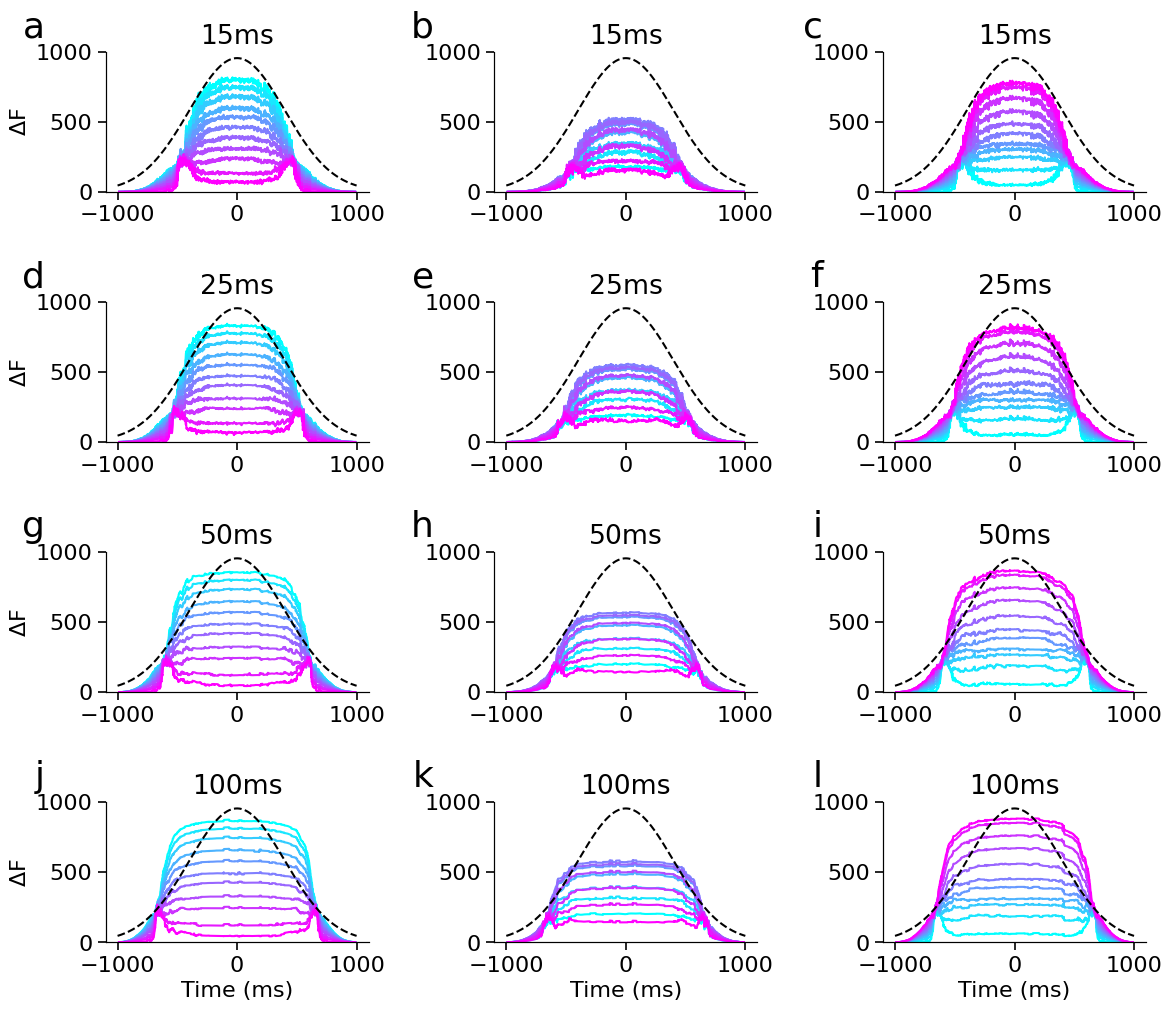

In [84]:
col_r = plt.cm.cool(np.linspace(0,1, num=n_layers))
fig=plt.figure(figsize=(12,10.5))
gs = GridSpec(4, 3)
snr=-20
labels=['a','b','c','d','e','f','g','h','i','j','k','l']
lab_idx=0
for w_idx, win_size in enumerate(win_sizes):
    
    all_m_array=np.array(matrices_all[win_size][snr])
    if len(all_m_array.shape)>1:
        m_mat=np.mean(all_m_array,axis=0)
        for l_idx,l in enumerate([0,5,10]):
            ax1=fig.add_subplot(gs[w_idx,l_idx])
            for i in range(n_layers):
                ax1.plot(woi_time,m_mat[i,l,:],color=col_r[i,:])
            ax2=ax1.twinx()
            ax2.plot(time*1000,signal,'k--')
            ax2.set_yticks([])
            ax1.set_title(f'{win_size}ms')
            if l_idx==0:
                ax1.set_ylabel(r"$\Delta$F")
            if w_idx==(len(win_sizes)-1):
                ax1.set_xlabel('Time (ms)')
            ax1.set_ylim([0,1000])
            ax1.set
            add_subplot_label(ax1, labels[lab_idx], x=-.23, y=1.3)
            lab_idx+=1
plt.tight_layout()
plt.savefig(f"figure_S1_snr_win_size.pdf")

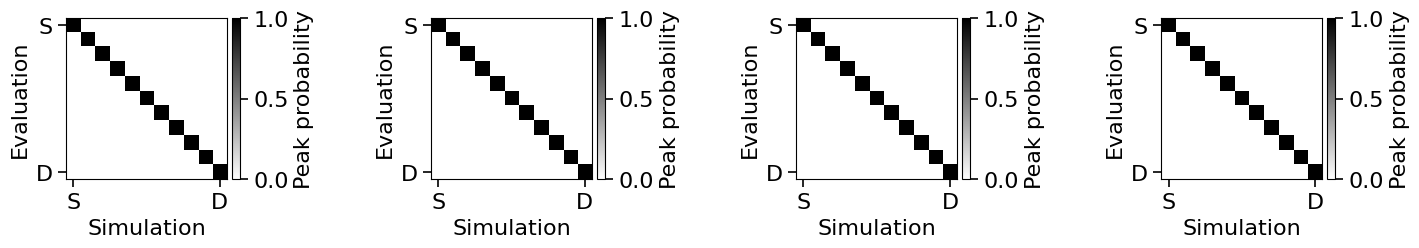

In [69]:
fig=plt.figure(figsize=(4*len(win_sizes), 3), facecolor="white")
gs = GridSpec(1, len(win_sizes))

plt.rcParams.update({
    'axes.spines.right': True,
    'axes.spines.top': True
})

divnorm = Normalize(vmin=0, vmax=1)
for w_idx, win_size in enumerate(win_sizes):
    ax = fig.add_subplot(gs[0,w_idx])
    m_mx = np.mean(annots_bin[snr][win_size], axis=0)
    iw = plot_mx(m_mx, ax=ax, labels=True, cmap="binary", norm=divnorm, cbar=True, cbar_label=r"Peak probability")
    
plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top': False
})
plt.savefig(f"figure_S1_snr_win_size_peak_prob.pdf")

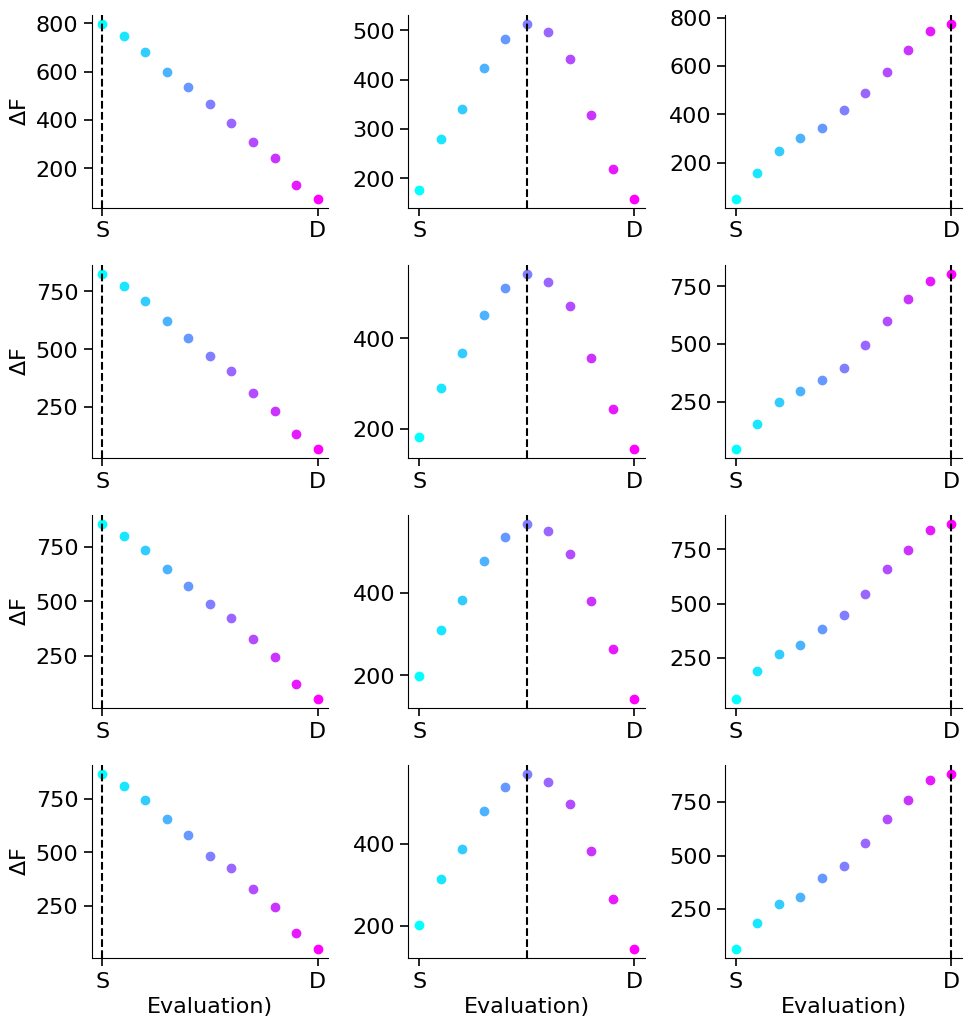

In [90]:
col_r = plt.cm.cool(np.linspace(0,1, num=n_layers))
fig=plt.figure(figsize=(10,10.5))
gs = GridSpec(4, 3)
snr=-20
for w_idx, win_size in enumerate(win_sizes):    
    all_m_array=np.array(matrices_all[win_size][snr])
    if len(all_m_array.shape)>1:
        m_mat=np.mean(all_m_array,axis=0)
        for l_idx,l in enumerate([0,5,10]):
            ax1=fig.add_subplot(gs[w_idx,l_idx])
            t_idx=int(m_mat.shape[2]/2)
            for i in range(n_layers):
                ax1.plot(i,m_mat[i,l,t_idx],'o',color=col_r[i,:])
            max_idx=np.argmax(m_mat[:,l,t_idx])
            ax1.axvline(max_idx,color='k',linestyle='--')
            if l_idx==0:
                ax1.set_ylabel(r"$\Delta$F")
            if w_idx==(len(win_sizes)-1):
                ax1.set_xlabel('Evaluation)') 
            ax1.set_xticks([0,n_layers-1])
            ax1.set_xticklabels(['S','D'])
plt.tight_layout()
plt.savefig(f"figure_SX_snr_win_size_central_slice.pdf")